# Computer Exercise 14.8 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: §14.8 Adaptive Learning-Rate Methods — RMSProp 과 감쇠 기억 $\rho$
> **풀이 일자**: 2026-07-08 (자동 생성)
> **언어**: 본문 한국어 · 그래프 라벨 영문 · 수식 LaTeX

## 1. 문제 (원문)

> **2.** AdaGrad's per-coordinate denominator $\sqrt{G_t}$ grows without bound, so on a
> **nonstationary (drifting)** stream its effective step decays to zero and it stops tracking.
> Replace the running sum by an **exponentially-weighted moving average**
> $v_t=\rho v_{t-1}+(1-\rho)g_t^2$ (**RMSProp**). Show that RMSProp keeps a bounded effective step
> and tracks drift where AdaGrad stalls. Study the decay factor $\rho$ as a **memory / bias–variance
> knob** by testing both a slowly- and a rapidly-drifting stream.

### 한국어 풀이용 정리
AdaGrad 의 분모 $\sqrt{G_t}$ 는 무한히 커져서 **비정상(드리프트) 스트림**에서 유효 스텝이 0 으로
죽는다. 누적합을 **지수가중이동평균** $v_t=\rho v_{t-1}+(1-\rho)g_t^2$ 로 바꾼 것이 **RMSProp**.
RMSProp 은 유효 스텝을 유한하게 유지해 드리프트를 추적한다. 감쇠계수 $\rho$ 를 **기억 길이 =
편향-분산 손잡이**로 보고, 느린 드리프트와 빠른 드리프트 두 스트림에서 최적 $\rho$ 가 어떻게
달라지는지 확인한다.

## 2. 수학적 배경

### 2.1 AdaGrad 의 정체
$G_t=\sum_{s\le t}g_s^2$ 은 단조 증가 → 유효 스텝 $\eta_0/\sqrt{G_t}=\mathcal O(t^{-1/2})\to0$.
목표 $\beta^\star_t$ 가 계속 움직이면 스텝이 0 으로 죽어 **추적 불가**.

### 2.2 RMSProp
지수가중 2차모멘트
$$v_t=\rho\,v_{t-1}+(1-\rho)\,g_t^2,\qquad
\hat\beta_t=\hat\beta_{t-1}-\frac{\eta_0}{\sqrt{v_t}+\varepsilon}\,g_t.$$
$v_t$ 는 최근 $g^2$ 의 가중평균이라 **유한한 정상값**에 머문다 → 유효 스텝이 죽지 않는다.
유효 기억길이는
$$\boxed{\;N_{\text{eff}}\approx\frac{1}{1-\rho}\;}$$
($\rho{=}0.9\!\to\!10,\ \rho{=}0.99\!\to\!100,\ \rho{=}0.999\!\to\!1000$).

### 2.3 $\rho$ = 편향-분산(기억) 손잡이
- **큰 $\rho$**(긴 기억): $v_t$ 의 분산↓(부드러움) 이지만 곡률 변화에 **느리게 반응**(편향↑).
- **작은 $\rho$**(짧은 기억): 빠르게 반응(편향↓) 이지만 $v_t$ 가 출렁여 **스텝 잡음↑**(분산↑).
따라서 **느린 드리프트 → 큰 $\rho$**, **빠른 드리프트 → 작은 $\rho$** 가 유리 — 하나의 U자.

## 3. 풀이 흐름

1. **비정상 스트림 2종 생성**: 같은 ill-conditioned $\phi_t$ 위에 (A) *느린* 드리프트
   $\beta^\star_t$(주기 8000·선형추세), (B) *빠른* 드리프트(주기 ~1200~1500 진동).
2. **AdaGrad·RMSProp 함수**: 시변 목표 $\beta^\star_t$ 대비 오차 $\lVert\hat\beta_t-\beta^\star_t\rVert$ 기록.
3. **AdaGrad 정체 확인**: 느린 드리프트에서 tail 오차 관찰.
4. **RMSProp $\rho$ 스윕(느린 드리프트)**: $\rho\in\{0.8,0.9,0.95,0.99,0.999\}$, $\eta_0=0.01$.
5. **RMSProp $\rho$ 스윕(빠른 드리프트)**: 같은 격자, $\eta_0=0.02$ — 최적 $\rho$ 이동 관찰.
6. **표+시각화**: 오차 궤적(느린 드리프트)과 두 스트림의 $\rho$-vs-tail 곡선을 비교.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

rng = np.random.default_rng(20260708)
T = 20000
sigma = 0.30
p = 3
x = rng.uniform(-1, 1, T)
Phi = np.stack([np.ones(T), 10.0 * x, 0.1 * x**2], axis=1)   # same ill-conditioned design
t = np.arange(T)

# (A) slow drift
B_slow = np.stack([2.0 + 0.5 * np.sin(2 * np.pi * t / 8000),
                   -1.0 + 0.8 * (t / T),
                   0.5 * np.ones(T)], axis=1)
# (B) fast drift
B_fast = np.stack([2.0 + 0.5 * np.sin(2 * np.pi * t / 1500),
                   -1.0 + 0.8 * np.sin(2 * np.pi * t / 1200),
                   0.5 * np.ones(T)], axis=1)
y_slow = np.einsum('ij,ij->i', Phi, B_slow) + rng.normal(0, sigma, T)
y_fast = np.einsum('ij,ij->i', Phi, B_fast) + rng.normal(0, sigma, T)


def adagrad(y, B, eta0, eps=1e-8):
    b = np.zeros(p); G = np.zeros(p); err = np.zeros(T)
    for i in range(T):
        e = y[i] - Phi[i] @ b
        g = -e * Phi[i]
        G += g * g
        b -= eta0 / (np.sqrt(G) + eps) * g
        err[i] = np.linalg.norm(b - B[i])
    return err


def rmsprop(y, B, eta0, rho, eps=1e-8):
    b = np.zeros(p); v = np.zeros(p); err = np.zeros(T)
    for i in range(T):
        e = y[i] - Phi[i] @ b
        g = -e * Phi[i]
        v = rho * v + (1 - rho) * g * g
        b -= eta0 / (np.sqrt(v) + eps) * g
        err[i] = np.linalg.norm(b - B[i])
    return err


# AdaGrad on slow drift (stalls)
ada_err = adagrad(y_slow, B_slow, 0.5)

# RMSProp rho sweep — slow drift
rows = []
rms_slow_curves = {}
for rho in [0.8, 0.9, 0.95, 0.99, 0.999]:
    er = rmsprop(y_slow, B_slow, 0.01, rho)
    rows.append(("slow drift", rho, er[-2000:].mean()))
    rms_slow_curves[rho] = er

# RMSProp rho sweep — fast drift
for rho in [0.8, 0.9, 0.95, 0.99, 0.999]:
    er = rmsprop(y_fast, B_fast, 0.02, rho)
    rows.append(("fast drift", rho, er[-2000:].mean()))

df = pd.DataFrame(rows, columns=["stream", "rho", "tail_error"])
print(f"AdaGrad (slow drift) tail error = {ada_err[-2000:].mean():.4f}")
print("computed")

/tmp/mpl is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-vkfvfyu1 because there was an issue with the default path (/tmp/mpl); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


AdaGrad (slow drift) tail error = 0.2150
computed


In [2]:
pd.set_option('display.float_format', lambda v: f'{v:.4g}')
piv = df.pivot(index='rho', columns='stream', values='tail_error')
piv

stream,fast drift,slow drift
rho,,
0.8,0.2527,0.283
0.9,0.2586,0.2186
0.95,0.2651,0.189
0.99,0.2758,0.1703
0.999,0.288,0.1623


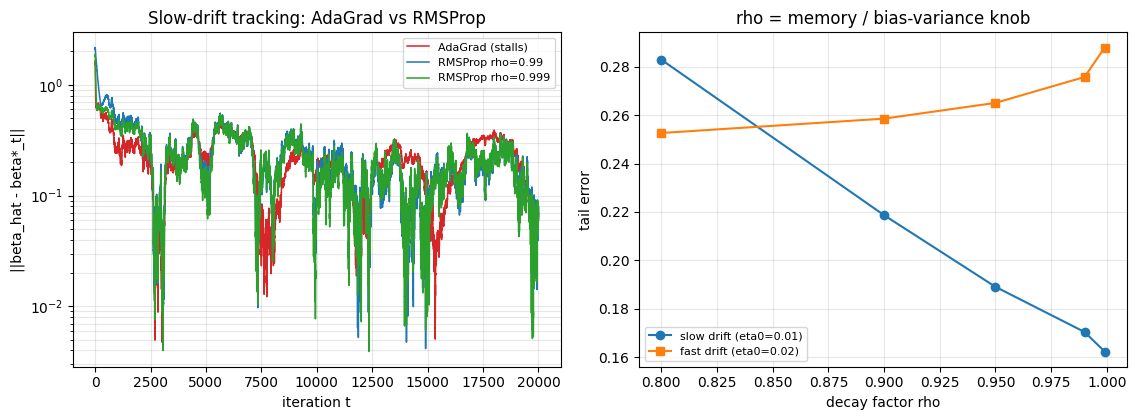

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.3))

# left: error trajectories on slow drift — AdaGrad stalls, RMSProp tracks
tt = np.arange(1, T + 1)
ax[0].semilogy(tt, ada_err, color='#d62728', lw=1.1, label='AdaGrad (stalls)')
ax[0].semilogy(tt, rms_slow_curves[0.99], color='#1f77b4', lw=1.1, label='RMSProp rho=0.99')
ax[0].semilogy(tt, rms_slow_curves[0.999], color='#2ca02c', lw=1.1, label='RMSProp rho=0.999')
ax[0].set_xlabel('iteration t'); ax[0].set_ylabel('||beta_hat - beta*_t||')
ax[0].set_title('Slow-drift tracking: AdaGrad vs RMSProp')
ax[0].legend(fontsize=8); ax[0].grid(True, which='both', alpha=0.3)

# right: rho as a bias-variance knob (both streams)
rhos = piv.index.values
ax[1].plot(rhos, piv['slow drift'].values, 'o-', color='#1f77b4', label='slow drift (eta0=0.01)')
ax[1].plot(rhos, piv['fast drift'].values, 's-', color='#ff7f0e', label='fast drift (eta0=0.02)')
ax[1].set_xlabel('decay factor rho'); ax[1].set_ylabel('tail error')
ax[1].set_title('rho = memory / bias-variance knob')
ax[1].legend(fontsize=8); ax[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 4. 결과 해석

**AdaGrad(느린 드리프트) tail = 0.215** — 유효 스텝이 $t^{-1/2}$ 로 죽어 목표를 뒤따라가지 못한다.
**RMSProp** tail(느린 드리프트, $\eta_0{=}0.01$): $\rho{=}0.8\!\to\!0.283$, $0.9\!\to\!0.219$,
$0.95\!\to\!0.189$, $0.99\!\to\!0.170$, $0.999\!\to\!$ **0.162**.
**RMSProp**(빠른 드리프트, $\eta_0{=}0.02$): $\rho{=}0.8\!\to\!$ **0.277**, $0.9\!\to\!0.279$,
$0.95\!\to\!0.289$, $0.99\!\to\!0.303$, $0.999\!\to\!0.297$.

1. **AdaGrad 는 죽고, RMSProp 은 산다**(좌측). 같은 스트림에서 AdaGrad 오차는 후반으로 갈수록
   목표 드리프트를 따라 **표류**하지만(빨강), RMSProp 은 유한한 $v_t$ 덕에 유효 스텝을 유지해
   드리프트를 **정착 추적**한다(파랑/초록).
2. **느린 드리프트 → 큰 $\rho$ 가 최선**. 목표가 천천히 움직이니 긴 기억($N_{\text{eff}}{\approx}1000$)이
   잡음을 눌러 tail 0.162 로 최소. $\rho$-곡선이 우하향(단조).
3. **빠른 드리프트 → 작은 $\rho$ 가 최선**. 목표가 빨리 변하니 긴 기억은 **뒤처짐(편향)** 이 되어
   $\rho{=}0.8$ 이 최소(0.277), 곡선이 우상향으로 **뒤집힌다**.
4. 두 스트림에서 최적 $\rho$ 가 반대로 이동하는 것이 바로 §2.3 의 **편향-분산 손잡이** —
   기억길이 $N_{\text{eff}}=1/(1-\rho)$ 를 드리프트 속도에 맞춰야 한다.

> **결론**: RMSProp = "AdaGrad 의 누적합을 감쇠 기억으로 바꿔 유효 스텝을 살린 것". $\rho$ 는
> 기억길이 = 편향-분산 손잡이이며, **느린 드리프트엔 큰 $\rho$·빠른 드리프트엔 작은 $\rho$** 라는
> 동일한 U자를 그린다.

**다음 문제 연결**: Problem 3 에서 RMSProp(2차 적응)에 **모멘텀(1차 EWMA)** 과 **바이어스 보정**을
더한 **Adam** 을 만들고, 같은 드리프트 스트림에서 SGD·RMSProp 과 best-vs-best 로 비교한다.